# Example 1: Stability of Nonlinear Systems (Discrete-Time)

We study a nonlinear, time-invariant, discrete-time system

$$x(k+1)=g(x(k))$$

with equilibrium at the origin, $g(0)=0$.

In this example, we keep things visual and simple:
1. Simulate trajectories in the phase plane.
2. Use a Lyapunov candidate $V(x)$.
3. Visualize $\Delta V(x)=V(g(x))-V(x)$ over a grid.
4. Explore behavior with one interactive slider panel.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, VBox, HBox
from IPython.display import display

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## Nonlinear Map and Lyapunov Candidate

We use a damped nonlinear map (Euler-discretized pendulum-like dynamics):

$$\begin{aligned}
x_1(k+1) &= x_1(k) + T_s\,x_2(k),\\
x_2(k+1) &= x_2(k) + T_s\left(-\sin(x_1(k)) - c\,x_2(k)\right).
\end{aligned}$$

Equilibrium: $x=0$.

Lyapunov candidate (energy-like):

$$V(x)=\frac{1}{2}(x_1^2+x_2^2), \qquad \Delta V(x)=V(g(x))-V(x).$$

For asymptotic stability intuition, we want to see trajectories approach the origin and mostly negative $\Delta V$ in a neighborhood.

In [6]:
# Nominal parameters
TS = 0.12
C_DAMP = 0.45


def g(x, ts=TS, c=C_DAMP):
    """Discrete-time nonlinear dynamics x(k+1)=g(x(k))."""
    x1, x2 = x
    x1_next = x1 + ts * x2
    x2_next = x2 + ts * (-np.sin(x1) - c * x2)
    return np.array([x1_next, x2_next], dtype=float)


def rollout(x0, steps=80, ts=TS, c=C_DAMP):
    """Simulate trajectory for a fixed number of steps."""
    traj = np.zeros((steps + 1, 2), dtype=float)
    traj[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        traj[k + 1] = g(traj[k], ts=ts, c=c)
    return traj


def V(x):
    """Quadratic Lyapunov candidate."""
    x = np.asarray(x, dtype=float)
    return 0.5 * (x[0] ** 2 + x[1] ** 2)


def delta_V(x, ts=TS, c=C_DAMP):
    """One-step Lyapunov change: V(g(x))-V(x)."""
    return V(g(x, ts=ts, c=c)) - V(x)


def delta_V_grid(x1_vals, x2_vals, ts=TS, c=C_DAMP):
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    DV = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            DV[i, j] = delta_V((X1[i, j], X2[i, j]), ts=ts, c=c)
    return X1, X2, DV

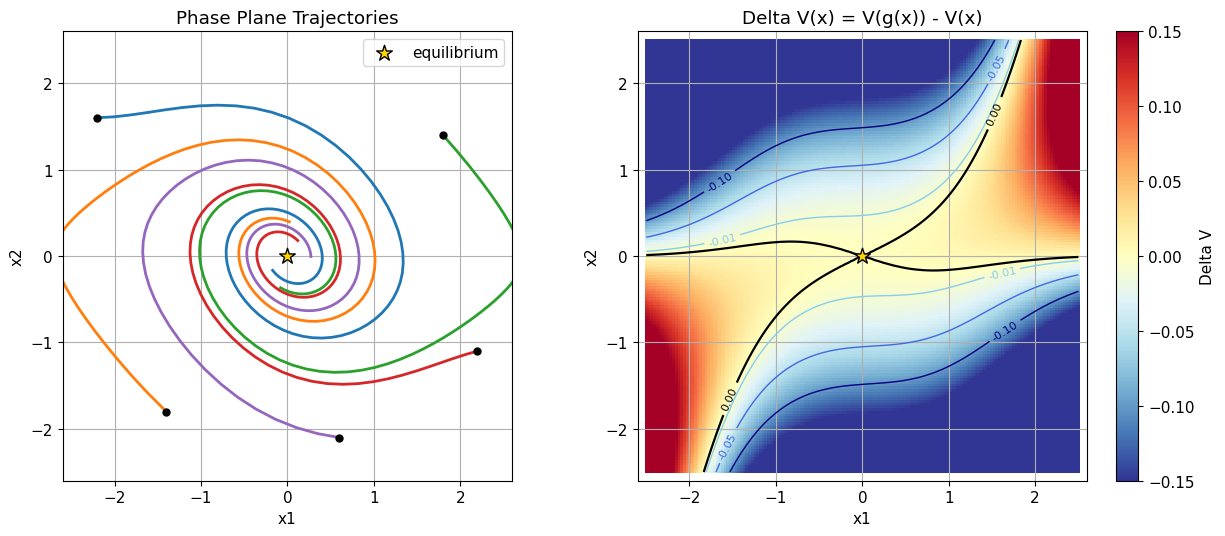

Fraction with Delta V <= 0 inside radius 1.25: 0.766


In [7]:
# Static visual overview: phase trajectories + Delta V map
x1_vals = np.linspace(-2.5, 2.5, 160)
x2_vals = np.linspace(-2.5, 2.5, 160)
X1, X2, DV = delta_V_grid(x1_vals, x2_vals, ts=TS, c=C_DAMP)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: trajectories in phase plane
ax = axes[0]
init_points = [
    (-2.2, 1.6),
    (-1.4, -1.8),
    (1.8, 1.4),
    (2.2, -1.1),
    (0.6, -2.1),
]
for x0 in init_points:
    tr = rollout(x0, steps=100)
    ax.plot(tr[:, 0], tr[:, 1], lw=2)
    ax.scatter([x0[0]], [x0[1]], s=25, color="black", zorder=5)

ax.scatter([0], [0], s=140, marker="*", color="gold", edgecolor="black", zorder=6, label="equilibrium")
ax.set_title("Phase Plane Trajectories")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")

# Right: Delta V over state space
ax2 = axes[1]
im = ax2.pcolormesh(X1, X2, DV, shading="auto", cmap="RdYlBu_r", vmin=-0.15, vmax=0.15)
cs = ax2.contour(X1, X2, DV, levels=[-0.10, -0.05, -0.01, 0.0], colors=["navy", "royalblue", "skyblue", "black"], linewidths=[1.0, 1.0, 1.0, 1.6])
ax2.clabel(cs, fmt="%.2f", fontsize=8)
ax2.scatter([0], [0], s=140, marker="*", color="gold", edgecolor="black", zorder=6)
ax2.set_title("Delta V(x) = V(g(x)) - V(x)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_xlim(-2.6, 2.6)
ax2.set_ylim(-2.6, 2.6)
ax2.set_aspect("equal", adjustable="box")
cb = plt.colorbar(im, ax=ax2)
cb.set_label("Delta V")

plt.tight_layout()
plt.show()

# Quick numerical check on the central neighborhood
grid_mask = (X1**2 + X2**2) <= 1.25**2
frac_nonpos = np.mean(DV[grid_mask] <= 1e-8)
print(f"Fraction with Delta V <= 0 inside radius 1.25: {frac_nonpos:.3f}")

## Interactive Exploration

Move the sliders to test Lyapunov-style behavior for different initial conditions and damping values.

Interpretation guide:
- If the trajectory stays near the origin after a small perturbation, this supports Lyapunov stability.
- If $V(k)$ decreases toward zero, this supports attractivity (asymptotic behavior in that region).

In [8]:
x1_0 = FloatSlider(value=1.6, min=-2.5, max=2.5, step=0.1, description="x1(0)", continuous_update=False)
x2_0 = FloatSlider(value=-1.0, min=-2.5, max=2.5, step=0.1, description="x2(0)", continuous_update=False)
c_slider = FloatSlider(value=C_DAMP, min=0.10, max=0.9, step=0.05, description="damping c", continuous_update=False)
steps_slider = IntSlider(value=80, min=20, max=160, step=10, description="steps", continuous_update=False)
out = widgets.Output()


def redraw(_=None):
    with out:
        out.clear_output(wait=True)

        x0 = np.array([x1_0.value, x2_0.value], dtype=float)
        c_here = c_slider.value
        n_steps = steps_slider.value
        tr = rollout(x0, steps=n_steps, ts=TS, c=c_here)
        v_seq = np.array([V(x) for x in tr])

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Left: phase trajectory
        ax = axes[0]
        ax.plot(tr[:, 0], tr[:, 1], color="crimson", lw=2.4, label="trajectory")
        ax.scatter([tr[0, 0]], [tr[0, 1]], color="black", s=40, zorder=5, label="start")
        ax.scatter([0], [0], s=140, marker="*", color="gold", edgecolor="black", zorder=6, label="equilibrium")
        ax.set_title("Phase Plane")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(-2.6, 2.6)
        ax.set_ylim(-2.6, 2.6)
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="upper right")

        # Right: Lyapunov sequence
        ax2 = axes[1]
        k = np.arange(len(v_seq))
        ax2.plot(k, v_seq, color="steelblue", lw=2.4)
        ax2.set_title("Lyapunov Candidate Along Trajectory")
        ax2.set_xlabel("k")
        ax2.set_ylabel("V(x(k))")

        # Display one-step Delta V statistics
        dv_seq = v_seq[1:] - v_seq[:-1]
        frac_nonpos = np.mean(dv_seq <= 1e-9) if len(dv_seq) > 0 else np.nan
        ax2.text(
            0.02,
            0.95,
            f"frac(Delta V <= 0): {frac_nonpos:.2f}",
            transform=ax2.transAxes,
            va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )

        plt.tight_layout()
        plt.show()


for w in [x1_0, x2_0, c_slider, steps_slider]:
    w.observe(redraw, names="value")

display(VBox([HBox([x1_0, x2_0]), HBox([c_slider, steps_slider]), out]))
redraw()

## What This Example Shows

1. The origin is an equilibrium of the nonlinear map.
2. For the shown parameter range and nearby initial conditions, trajectories move toward the origin.
3. The map of $\Delta V$ is mostly negative near the origin, supporting Lyapunov-style local asymptotic stability intuition.

Try this:
1. Set damping $c$ close to 0.05 and compare convergence speed.
2. Increase the initial condition magnitude and check where behavior stops looking strongly contractive.
3. Compare the phase-plot path with the $V(x(k))$ curve.